In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("../data/clean_hdb.csv")

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nDate range: {df['month'].min()} to {df['month'].max()}")
print(f"\nBasic stats:")
df.describe()

Shape: (10000, 11)

Columns: ['month', 'town', 'flat_type', 'block', 'street_name', 'floor_area_sqm', 'flat_model', 'lease_commence_date', 'resale_price', 'storey_mid', 'remaining_lease_years']

Date range: 2025-12-01 to 2026-04-01

Basic stats:


,floor_area_sqm,lease_commence_date,resale_price,storey_mid,remaining_lease_years
count,10000.00000,10000.000000,1.000000e+04,10000.000000,10000.000000
mean,95.28549,1998.578000,6.587250e+05,4.247100,72.011850
std,23.82812,15.221658,2.108629e+05,3.370998,15.256305
min,31.00000,1966.000000,2.388880e+05,0.500000,39.800000
25%,74.00000,1985.000000,5.117500e+05,2.000000,58.775000
50%,93.00000,1998.000000,6.300000e+05,3.500000,71.200000
75%,112.00000,2015.000000,7.750000e+05,5.500000,88.300000
max,193.00000,2022.000000,1.728000e+06,25.000000,94.900000


In [2]:
print("Null counts:")
print(df.isnull().sum())

print(f"\nFlat types: {df['flat_type'].unique()}")
print(f"\nNumber of towns: {df['town'].nunique()}")
print(f"\nTowns: {df['town'].unique()}")

Null counts:
month                    0
town                     0
flat_type                0
block                    0
street_name              0
floor_area_sqm           0
flat_model               0
lease_commence_date      0
resale_price             0
storey_mid               0
remaining_lease_years    0
dtype: int64

Flat types: ['2 ROOM' '3 ROOM' '4 ROOM' '5 ROOM' 'EXECUTIVE' '1 ROOM'
 'MULTI-GENERATION']

Number of towns: 26

Towns: ['ANG MO KIO' 'BEDOK' 'BISHAN' 'BUKIT BATOK' 'BUKIT MERAH' 'BUKIT PANJANG'
 'BUKIT TIMAH' 'CENTRAL AREA' 'CHOA CHU KANG' 'CLEMENTI' 'GEYLANG'
 'HOUGANG' 'JURONG EAST' 'JURONG WEST' 'KALLANG/WHAMPOA' 'MARINE PARADE'
 'PASIR RIS' 'PUNGGOL' 'QUEENSTOWN' 'SEMBAWANG' 'SENGKANG' 'SERANGOON'
 'TAMPINES' 'TOA PAYOH' 'WOODLANDS' 'YISHUN']


## Price Distribution

The resale price distribution is right-skewed, with most transactions between 500k-700k.
A small number of premium flats push the mean to 658,725.
May need log transformation before modelling.

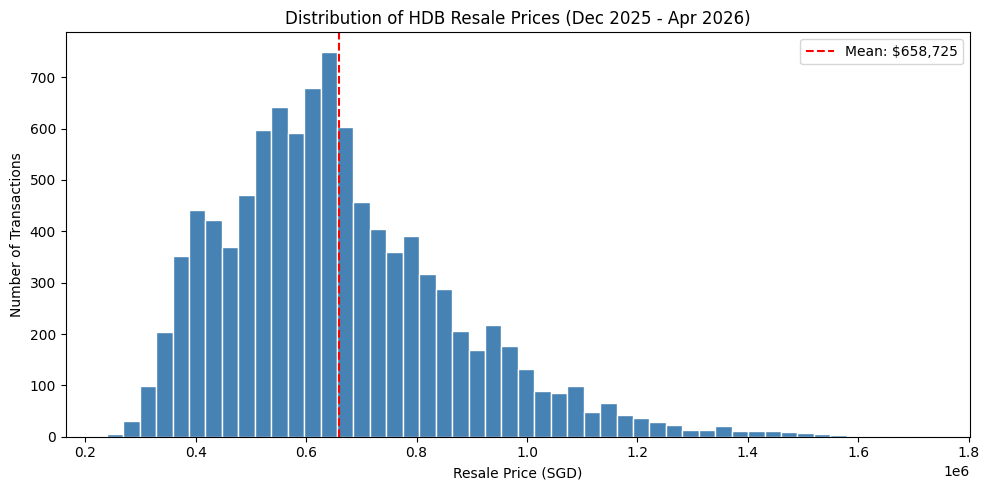

In [4]:
# Price distribution
plt.figure(figsize=(10, 5))
plt.hist(df['resale_price'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of HDB Resale Prices (Dec 2025 - Apr 2026)')
plt.xlabel('Resale Price (SGD)')
plt.ylabel('Number of Transactions')
plt.axvline(df['resale_price'].mean(), color='red', linestyle='--', label=f"Mean: ${df['resale_price'].mean():,.0f}")
plt.legend()
plt.tight_layout()
plt.show()

## Price by Flat Type

Resale price increases consistently with flat size, from 1-room at around 260k to Multi-Generation at around 1.1M. 
Flat type is clearly a strong predictor of price and will likely be one of the most important features in the ML model. 
Executive and Multi-Generation command a significant premium over standard 5-room flats.

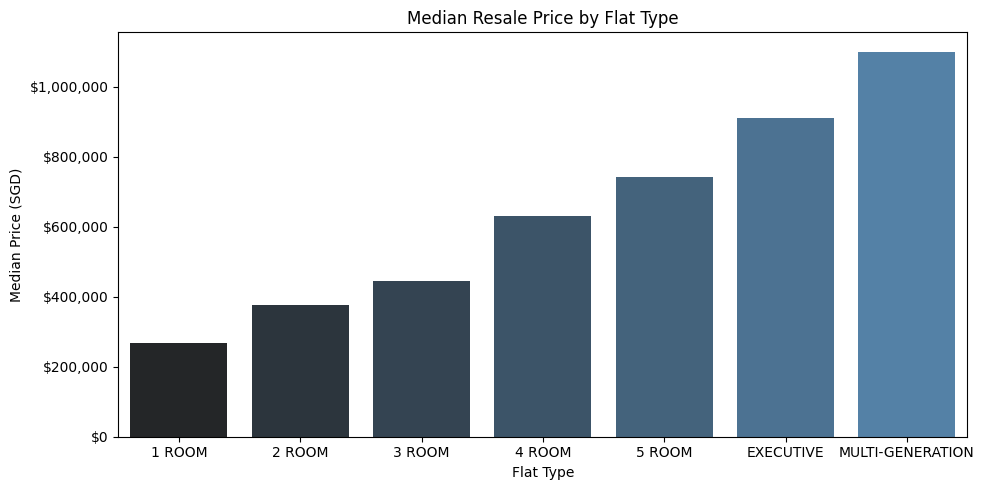

In [7]:
median_by_type = df.groupby('flat_type')['resale_price'].median().sort_values().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=median_by_type, x='flat_type', y='resale_price', hue='flat_type', palette='dark:steelblue', legend=False)
plt.title('Median Resale Price by Flat Type')
plt.xlabel('Flat Type')
plt.ylabel('Median Price (SGD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

## Price by Town

Location has the largest price variation of any feature. Bukit Timah median is almost double Jurong East.
Central and mature estates (Bishan, Queenstown, Toa Payoh) command significant premiums.
Town will be a critical feature in the ML model.

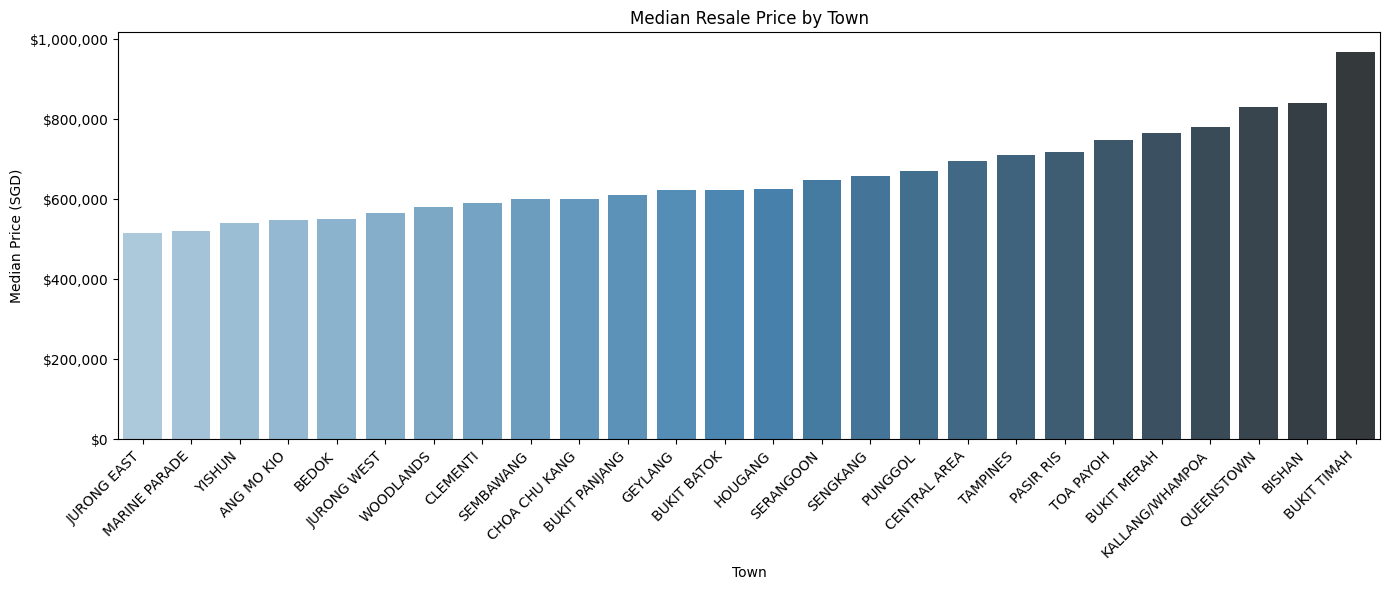

In [8]:
median_by_town = df.groupby('town')['resale_price'].median().sort_values().reset_index()

plt.figure(figsize=(14, 6))
sns.barplot(data=median_by_town, x='town', y='resale_price', hue='town', legend=False, palette='Blues_d')
plt.title('Median Resale Price by Town')
plt.xlabel('Town')
plt.ylabel('Median Price (SGD)')
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

## Price vs Floor Area

Clear positive correlation between floor area and price.
Vertical strips visible due to HDB standardised flat sizes.
Large spread at bigger sizes shows floor area alone is insufficient, things like 
location and other features are needed to explain the price variation.

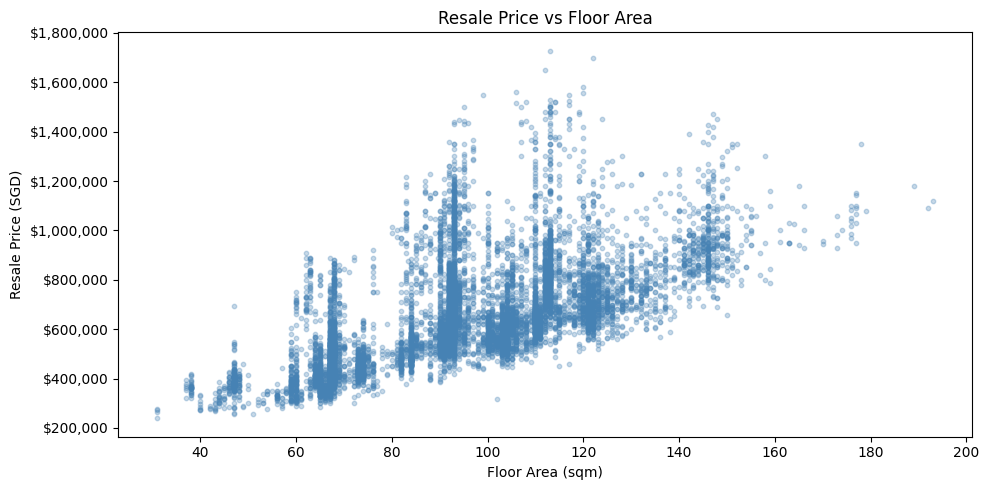

In [10]:
plt.figure(figsize=(10, 5))
plt.scatter(df['floor_area_sqm'], df['resale_price'], alpha=0.3, color='steelblue', s=10)
plt.title('Resale Price vs Floor Area')
plt.xlabel('Floor Area (sqm)')
plt.ylabel('Resale Price (SGD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

## Price vs Storey

Vertical strips appear because HDB uses standardised storey ranges.
Weak positive correlation, with higher floors command a slight premium.
However storey alone is a weak predictor compared to town and flat type.

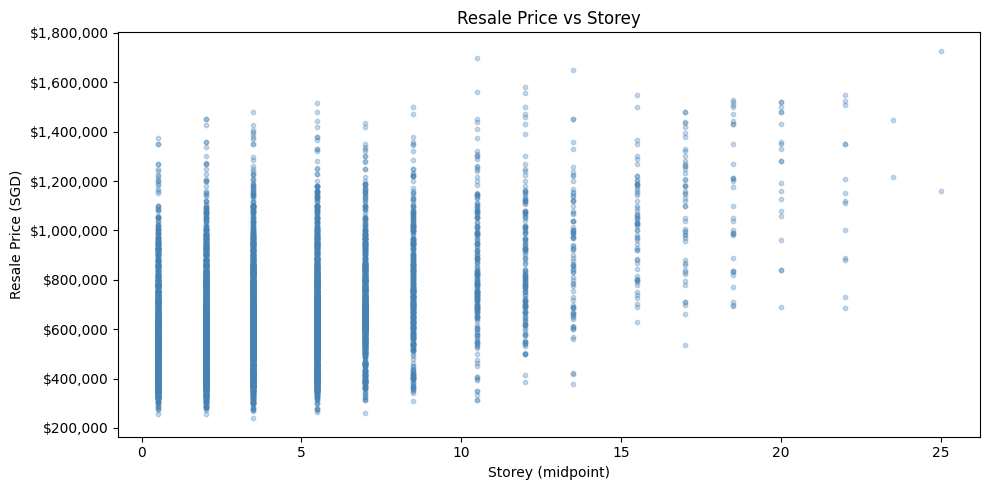

In [12]:
plt.figure(figsize=(10, 5))
plt.scatter(df['storey_mid'], df['resale_price'], alpha=0.3, color='steelblue', s=10)
plt.title('Resale Price vs Storey')
plt.xlabel('Storey (midpoint)')
plt.ylabel('Resale Price (SGD)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

## Correlation Heatmap

floor_area_sqm is the strongest numeric predictor of resale price (0.63).
lease_commence_date and remaining_lease_years are perfectly correlated (1.00), I
will drop one before modelling to avoid multicollinearity.
storey_mid has a weak but positive correlation (0.39).
Note: town and flat_type are categorical and not shown here  
but from earlier charts they are likely the strongest predictors overall.

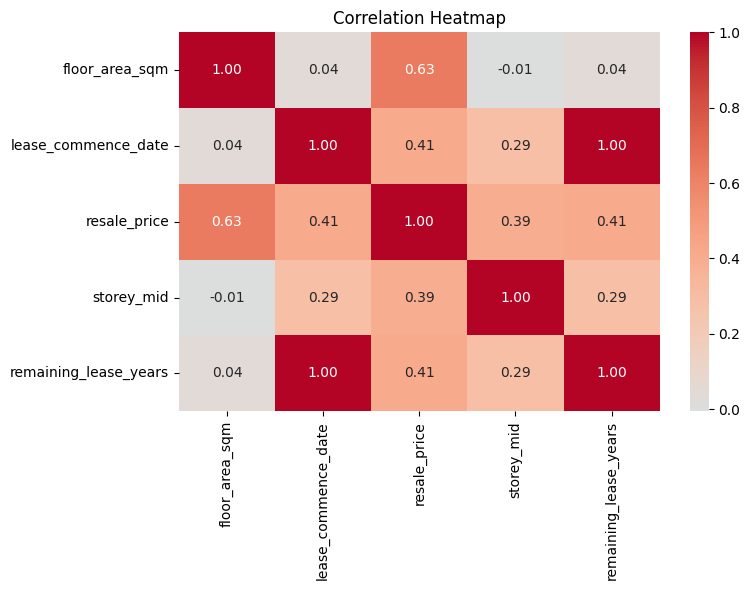

In [13]:
numeric_cols = ['floor_area_sqm', 'lease_commence_date', 'resale_price', 'storey_mid', 'remaining_lease_years']

corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()